# SynBO Optimization Demo

This notebook demonstrates a complete **multi-objective reaction optimization** workflow
using SynBO on a cobalt-catalyzed asymmetric reaction example.

- **Reaction space**: 5 reagent types x 58,320 combinations
- **Objectives**: Maximize yield and ee


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from synbo import ReactionOptimizer
from synbo.utils import load_desc_dict, get_prev_rxn
from virtual_experiment import virtual_experiment

sns.set_style('whitegrid')
%matplotlib inline

print('SynBO imported successfully')


SynBO imported successfully


## Step 1: Load the Example Reaction Space

The reaction space defines all possible reagent choices.
Each CSV file contains SMILES strings and reagent names.


In [2]:
EXAMPLE_DIR = Path('.').resolve()

reagent_types = ['alkali', 'cobalt_catalyst', 'organo_catalyst', 'oxidant', 'solvent']

desc_dict, condition_dict = load_desc_dict(
    reagent_types=reagent_types,
    desc_dir=str(EXAMPLE_DIR / 'descriptors'),
    name_suffix='_RDKit',
    index_col='name',
    return_condition_dict=True,
)

print('Reaction Space Summary:')
print('-' * 50)
total = 1
for rtype, values in condition_dict.items():
    count = len(values)
    total *= count
    print(f'  {rtype:25s}: {count:3d} options')
print(f'  Total combinations: {total:,}')
print(f'  Descriptor dimensions: {sum(df.shape[1] for df in desc_dict.values())}')


Reaction Space Summary:
--------------------------------------------------
  alkali                   :   8 options
  cobalt_catalyst          :   8 options
  organo_catalyst          :   9 options
  oxidant                  :   8 options
  solvent                  :  10 options
  Total combinations: 46,080
  Descriptor dimensions: 1057


## Step 2: Initial Sampling (Batch 0)

The first batch uses **Latin Hypercube Sampling (LHS)**
to generate a space-filling initial design.


In [3]:
optimizer_init = ReactionOptimizer(
    opt_metrics=['yield', 'ee'],
    opt_type='init',
    random_seed=42,
    save_dir=str(EXAMPLE_DIR / 'results'),
)
optimizer_init.load_rxn_space(condition_dict)
optimizer_init.load_desc(desc_dict)
optimizer_init.initialize(batch_size=8, sampling_method='lhs')
optimizer_init.save_results(filetype='csv')

print('Initial batch recommended:')
for i, cond in enumerate(optimizer_init.selected_conditions):
    print(f'  {i+1}. {dict(zip(reagent_types, cond))}')


╭───── Reaction Optimizer ──────╮
│ ReactionOptimizer initialized │
│ Metrics: yield, ee            │
│ Mode: init                    │
╰───────────────────────────────╯

                 🔬 Reaction Space Summary                  
┏━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Condition Type  ┃ Count ┃ Sample Values                  ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ alkali          │     8 │ DABCO, DBU, KH2PO4...          │
│ cobalt_catalyst │     8 │ [Co]-1, [Co]-2, [Co]-3...      │
│ organo_catalyst │     9 │ (S)-Proline, BINOL-PA, DPEN... │
│ oxidant         │     8 │ Cl-1, Cl-2, F-1_BF4...         │
│ solvent         │    10 │ CH3CN, Chloroform, DCE...      │
└─────────────────┴───────┴────────────────────────────────┘

✓ Descriptors loaded successfully

Using 'auto_select' to refine descriptors...

Warning: Could not reach 200 even at threshold 0.5. Using current best.

...

Sampling 8 conditions using lhs method

Output()

✓ Selected 8 initial conditions using lhs sampling

✓ Saved recommendations to: /home/tzz/AIChem/synbo/examples/results/batch-0_20260506.csv

Initial batch recommended:
  1. {'alkali': 'no_alkali', 'cobalt_catalyst': '[Co]-5', 'organo_catalyst': 'BINOL-PA', 'oxidant': 'F_OTf', 'solvent': 'CH3CN'}
  2. {'alkali': 'DABCO', 'cobalt_catalyst': '[Co]-8', 'organo_catalyst': 'Quinine', 'oxidant': 'F_OTf', 'solvent': 'Ether'}
  3. {'alkali': 'acetic acid', 'cobalt_catalyst': '[Co]-6', 'organo_catalyst': 'DPEN', 'oxidant': 'NCS', 'solvent': 'Chloroform'}
  4. {'alkali': 'DBU', 'cobalt_catalyst': '[Co]-8', 'organo_catalyst': 'Hayashi-Jorgensen', 'oxidant': 'Iodine_ox', 'solvent': 'Chloroform'}
  5. {'alkali': 'no_alkali', 'cobalt_catalyst': '[Co]-5', 'organo_catalyst': 'Quinine', 'oxidant': 'Cl-2', 'solvent': 'HFIP'}
  6. {'alkali': 'DBU', 'cobalt_catalyst': '[Co]-7', 'organo_catalyst': 'Hayashi-Jorgensen', 'oxidant': 'Cl-1', 'solvent': 'HFIP'}
  7. {'alkali': 'acetic acid', 'cobalt_catalyst': '[Co]-5', 'organo_catalyst': 'Me-CBS', 'oxidant': 'NCS', 'solvent': 'THF'}
  8. {'alkali': 'DBU', 'cobalt_catalyst': '[Co]-7', 'organo_catalyst

## Step 3: Simulate Experimental Results

In a real workflow, you would run experiments and fill in actual yield/ee values.
Here we simulate results for demonstration.


In [4]:
batch0_file = list((EXAMPLE_DIR / 'results').glob('batch-0_*.csv'))[0]
batch0_data = virtual_experiment(batch0_file, seed=42)

print(f'Simulated {len(batch0_data)} experimental results:')
display(batch0_data[['alkali', 'cobalt_catalyst', 'organo_catalyst', 'yield', 'ee']].round(1))


Simulated 5 experimental results:


,alkali,cobalt_catalyst,organo_catalyst,yield,ee
0,DBU,[Co]-5,Me-CBS,50.6,48.6
1,no_alkali,[Co]-2,Hayashi-Jorgensen,82.3,43.2
2,no_alkali,[Co]-8,(S)-Proline,70.3,87.6
3,DBU,[Co]-5,Hayashi-Jorgensen,62.9,73.1
4,acetic acid,[Co]-5,MacMillan Gen 1,38.6,78.9


## Step 4: Bayesian Optimization (Batch 1)

Now we use the experimental results from Batch 0
to train a surrogate model and recommend the next batch.


In [5]:
optimizer_opt = ReactionOptimizer(
    opt_metrics=['yield', 'ee'],
    opt_type='auto',
    random_seed=42,
    save_dir=str(EXAMPLE_DIR / 'results'),
)
optimizer_opt.load_rxn_space(condition_dict)
optimizer_opt.load_desc(desc_dict)
optimizer_opt.load_prev_rxn(batch0_data)
optimizer_opt.optimize(batch_size=5)
optimizer_opt.save_results(filetype='csv')

print('Batch 1 recommendations:')
for i, (cond, rtype, pred_mean, pred_std) in enumerate(zip(
    optimizer_opt.selected_conditions,
    optimizer_opt.recommend_type,
    optimizer_opt.pred_mean,
    optimizer_opt.pred_std
)):
    print(f'  {i+1}. [{rtype}] {dict(zip(reagent_types, cond))}')
    print(f'       Pred yield: {pred_mean[0]:.1f}+/-{pred_std[0]:.1f} | Pred ee: {pred_mean[1]:.1f}+/-{pred_std[1]:.1f}')

explore = sum(1 for t in optimizer_opt.recommend_type if t.lower() == 'explore')
exploit = sum(1 for t in optimizer_opt.recommend_type if t.lower() == 'exploit')
print(f'  Explore: {explore} | Exploit: {exploit}')


╭───── Reaction Optimizer ──────╮
│ ReactionOptimizer initialized │
│ Metrics: yield, ee            │
│ Mode: auto                    │
╰───────────────────────────────╯

                 🔬 Reaction Space Summary                  
┏━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Condition Type  ┃ Count ┃ Sample Values                  ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ alkali          │     8 │ DABCO, DBU, KH2PO4...          │
│ cobalt_catalyst │     8 │ [Co]-1, [Co]-2, [Co]-3...      │
│ organo_catalyst │     9 │ (S)-Proline, BINOL-PA, DPEN... │
│ oxidant         │     8 │ Cl-1, Cl-2, F-1_BF4...         │
│ solvent         │    10 │ CH3CN, Chloroform, DCE...      │
└─────────────────┴───────┴────────────────────────────────┘

✓ Descriptors loaded successfully

✓ Loaded 5 previous reactions

Using 'auto_select' to refine descriptors...

...

[09:38:03 PM] Fitting model for 2th model...                                                          ]8;id=14302742;file:///home/tzz/AIChem/synbo/src/synbo/algorithm/bo_core.py\bo_core.py]8;;\:]8;id=14302743;file:///home/tzz/AIChem/synbo/src/synbo/algorithm/bo_core.py#98\98]8;;\
Training surrogate models ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 -:--:--

✅ Finish optimization

╭────────────────────────────────────────────── 🎯 Results Summary ───────────────────────────────────────────────╮
│ Optimization Complete!                                                                                          │
│ Recommended: 5 conditions                                                                                       │
│ Exploit: 0 | Explore: 0                                                                                         │
│ Method: default_BO | Device: cuda                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

✓ Saved recommendations to: /home/tzz/AIChem/synbo/examples/results/batch-1_20260506.csv

Batch 1 recommendations:
  1. [Unknown] {'alkali': 'no_alkali', 'cobalt_catalyst': '[Co]-3', 'organo_catalyst': 'BINOL-PA', 'oxidant': 'Iodine_ox', 'solvent': 'HFIP'}
       Pred yield: 63.6+/-34.4 | Pred ee: 65.8+/-39.7
  2. [Unknown] {'alkali': 'no_alkali', 'cobalt_catalyst': '[Co]-8', 'organo_catalyst': 'BINOL-PA', 'oxidant': 'K2S2O8', 'solvent': 'DCM'}
       Pred yield: 69.0+/-18.1 | Pred ee: 72.8+/-22.5
  3. [Unknown] {'alkali': 'no_alkali', 'cobalt_catalyst': '[Co]-7', 'organo_catalyst': 'BINOL-PA', 'oxidant': 'K2S2O8', 'solvent': 'HFIP'}
       Pred yield: 58.7+/-34.8 | Pred ee: 67.4+/-40.1
  4. [Unknown] {'alkali': 'no_alkali', 'cobalt_catalyst': '[Co]-4', 'organo_catalyst': 'Quinine', 'oxidant': 'Iodine_ox', 'solvent': 'THF'}
       Pred yield: 68.7+/-17.8 | Pred ee: 69.7+/-22.0
  5. [Unknown] {'alkali': 'no_alkali', 'cobalt_catalyst': '[Co]-6', 'organo_catalyst': 'Quinine', 'oxidant': 'K2S2O8', 'solvent': 'HFIP'}
       Pred yield: 59.8+/-34.4 | Pred ee: 64.3+/-39.8
  Explor

## Step 5: Simulate More Rounds

We simulate several rounds of optimization to show how the Pareto front evolves.


In [ ]:
# virtual_experiment function is defined in virtual_experiment.py
# It reads a saved batch CSV, randomly generates yield/ee values,
# writes them back to disk, and returns the updated DataFrame.


In [6]:
all_data = batch0_data.copy()
n_rounds = 6

for round_num in range(1, n_rounds + 1):
    opt = ReactionOptimizer(opt_metrics=['yield', 'ee'], opt_type='auto',
        random_seed=42 + round_num, save_dir=str(EXAMPLE_DIR / 'results'))
    opt.load_rxn_space(condition_dict)
    opt.load_desc(desc_dict)
    opt.load_prev_rxn(all_data)
    opt.optimize(batch_size=5)

    # Save recommended conditions to results directory (creates CSV with
    # [exp_data] placeholders for yield/ee)
    opt.save_results(filetype='csv')

    # Find the saved CSV file and simulate experimental results on disk
    batch_file = list((EXAMPLE_DIR / 'results').glob(f'batch-{opt.batch_id}_*.csv'))[0]
    virtual_experiment(batch_file, seed=42 + round_num)

    # Reload the updated data from disk (always reads from saved file)
    new_data = pd.read_csv(batch_file)

    all_data = pd.concat([all_data, new_data], ignore_index=True)
    print(f'Round {round_num}: +{len(new_data)} experiments, total: {len(all_data)}')

print(f'\nSimulated {len(all_data)} experiments across {n_rounds + 1} batches')


╭───── Reaction Optimizer ──────╮
│ ReactionOptimizer initialized │
│ Metrics: yield, ee            │
│ Mode: auto                    │
╰───────────────────────────────╯

                 🔬 Reaction Space Summary                  
┏━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Condition Type  ┃ Count ┃ Sample Values                  ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ alkali          │     8 │ DABCO, DBU, KH2PO4...          │
│ cobalt_catalyst │     8 │ [Co]-1, [Co]-2, [Co]-3...      │
│ organo_catalyst │     9 │ (S)-Proline, BINOL-PA, DPEN... │
│ oxidant         │     8 │ Cl-1, Cl-2, F-1_BF4...         │
│ solvent         │    10 │ CH3CN, Chloroform, DCE...      │
└─────────────────┴───────┴────────────────────────────────┘

✓ Descriptors loaded successfully

✓ Loaded 5 previous reactions

Using 'auto_select' to refine descriptors...

...

[09:45:22 PM] Fitting model for 1th model...                                                          ]8;id=14302808;file:///home/tzz/AIChem/synbo/src/synbo/algorithm/bo_core.py\bo_core.py]8;;\:]8;id=14302809;file:///home/tzz/AIChem/synbo/src/synbo/algorithm/bo_core.py#98\98]8;;\
Training surrogate models ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 -:--:--

[09:45:40 PM] Fitting model for 2th model...                                                          ]8;id=14302814;file:///home/tzz/AIChem/synbo/src/synbo/algorithm/bo_core.py\bo_core.py]8;;\:]8;id=14302815;file:///home/tzz/AIChem/synbo/src/synbo/algorithm/bo_core.py#98\98]8;;\
Training surrogate models ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 -:--:--

✅ Finish optimization

╭────────────────────────────────────────────── 🎯 Results Summary ───────────────────────────────────────────────╮
│ Optimization Complete!                                                                                          │
│ Recommended: 5 conditions                                                                                       │
│ Exploit: 0 | Explore: 0                                                                                         │
│ Method: default_BO | Device: cuda                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Round 6: +5 experiments, total: 35
Simulated 35 experiments across 7 batches


## Step 6: Visualize the Pareto Front

The **Pareto front** shows the trade-off between yield and ee.
Points on the front are non-dominated.


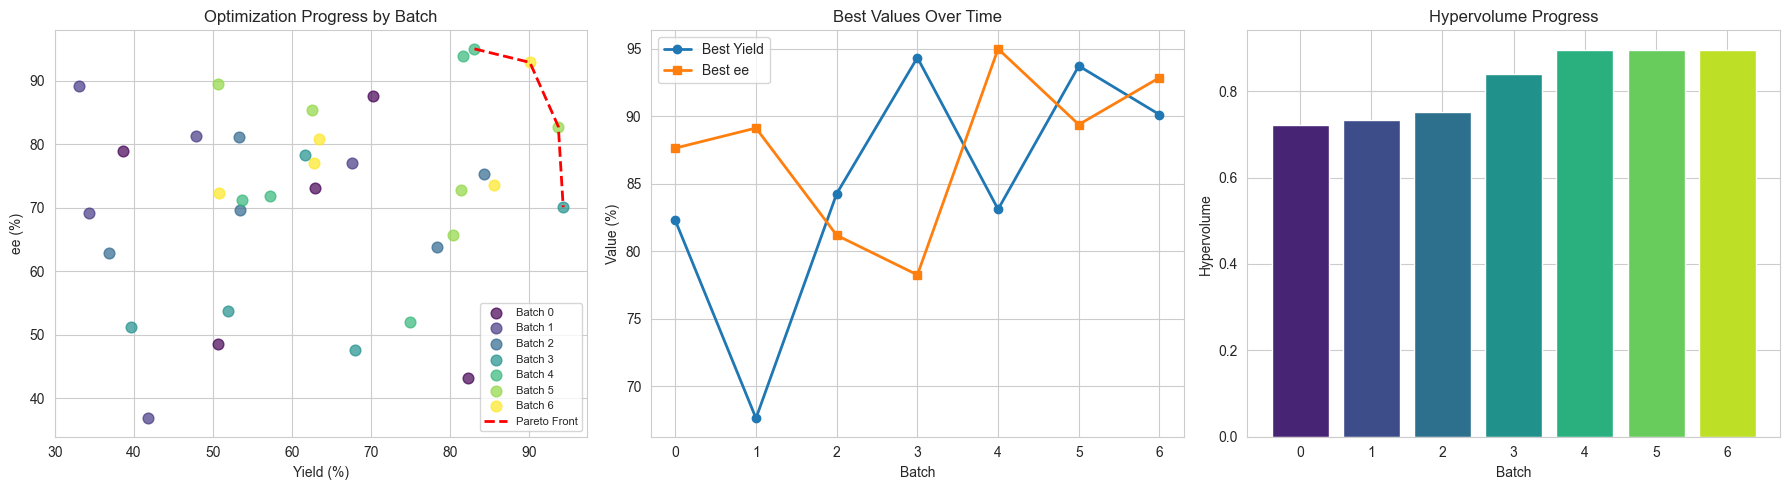

Final Pareto front: 4 points
Best yield: 94.3%
Best ee: 95.0%


In [7]:
def get_pareto_front(x, y):
    points = np.column_stack([x, y])
    is_pareto = np.ones(len(points), dtype=bool)
    for i in range(len(points)):
        for j in range(len(points)):
            if all(points[j] >= points[i]) and any(points[j] > points[i]):
                is_pareto[i] = False
                break
    return is_pareto

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

batch_ids = sorted(all_data['batch'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(batch_ids)))

for bid, color in zip(batch_ids, colors):
    batch_data = all_data[all_data['batch'] == bid]
    axes[0].scatter(batch_data['yield'], batch_data['ee'],
        color=color, label=f'Batch {int(bid)}', alpha=0.7, s=60)

pareto_mask = get_pareto_front(all_data['yield'].values, all_data['ee'].values)
pareto_points = all_data[pareto_mask].sort_values('yield')
axes[0].plot(pareto_points['yield'], pareto_points['ee'],
    'r--', linewidth=2, label='Pareto Front')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('Yield (%)')
axes[0].set_ylabel('ee (%)')
axes[0].set_title('Optimization Progress by Batch')

best_per_batch = all_data.groupby('batch').agg({'yield': 'max', 'ee': 'max'})
axes[1].plot(best_per_batch.index, best_per_batch['yield'], 'o-', label='Best Yield', linewidth=2)
axes[1].plot(best_per_batch.index, best_per_batch['ee'], 's-', label='Best ee', linewidth=2)
axes[1].set_xlabel('Batch')
axes[1].set_ylabel('Value (%)')
axes[1].set_title('Best Values Over Time')
axes[1].legend()

hv_values = []
for bid in batch_ids:
    batch_subset = all_data[all_data['batch'] <= bid]
    pmask = get_pareto_front(batch_subset['yield'].values, batch_subset['ee'].values)
    pareto = batch_subset[pmask]
    hv = np.prod(np.maximum(pareto[['yield', 'ee']].values / 100.0, 0).max(axis=0))
    hv_values.append(hv)

axes[2].bar(batch_ids, hv_values, color=plt.cm.viridis(np.linspace(0.1, 0.9, len(batch_ids))))
axes[2].set_xlabel('Batch')
axes[2].set_ylabel('Hypervolume')
axes[2].set_title('Hypervolume Progress')

plt.tight_layout()
plt.show()

print(f'Final Pareto front: {pareto_mask.sum()} points')
print(f'Best yield: {all_data["yield"].max():.1f}%')
print(f'Best ee: {all_data["ee"].max():.1f}%')


## Step 7: Final Pareto Front

Final visualization with the ideal point (100% yield, 100% ee).


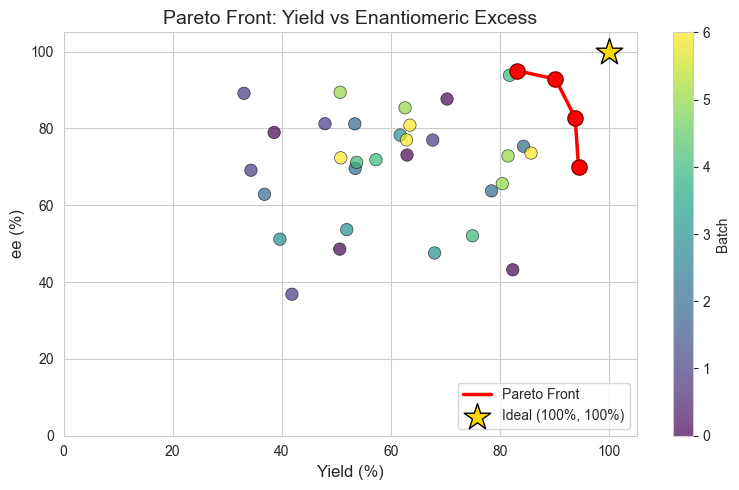

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(all_data['yield'], all_data['ee'],
    c=all_data['batch'], cmap='viridis', s=80, alpha=0.7, edgecolors='k', linewidth=0.5)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Batch')

pareto_mask = get_pareto_front(all_data['yield'].values, all_data['ee'].values)
pareto_points = all_data[pareto_mask].sort_values('yield')
ax.plot(pareto_points['yield'], pareto_points['ee'],
    'r-', linewidth=2.5, label='Pareto Front', zorder=5)
ax.scatter(pareto_points['yield'], pareto_points['ee'],
    color='red', s=120, zorder=6, edgecolors='darkred')

ax.scatter([100], [100], marker='*', color='gold', s=400,
    edgecolors='black', zorder=7, label='Ideal (100%, 100%)')

ax.set_xlabel('Yield (%)', fontsize=12)
ax.set_ylabel('ee (%)', fontsize=12)
ax.set_title('Pareto Front: Yield vs Enantiomeric Excess', fontsize=14)
ax.legend(loc='lower right')
ax.set_xlim(0, 105)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()


## Summary

This notebook demonstrated:

1. **Reaction Space Loading** - 5 reagent types, ~58k combinations
2. **Initial Sampling** - LHS generates an informative first batch
3. **Bayesian Optimization** - Multi-objective BO with explore/exploit trade-off
4. **Pareto Front Visualization** - Trade-off between yield and ee
5. **Hypervolume Tracking** - Quantitative measure of optimization progress

### Key Takeaways
- SynBO converges toward the Pareto front as more batches are evaluated
- Predictions include uncertainty estimates to help prioritize experiments
- Hypervolume increases as better trade-off points are discovered
- The framework supports both CLI and Python API workflows
